## **World Cities Population**

DATASET : https://www.kaggle.com/datasets/donatoriccio/world-cities-population-cleaned-version?resource=download

In [ ]:
# temel veri işleme kütüphaneleri
import pandas as pd
import numpy as np

# görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

#istatistik kütüphaneleri
from scipy import stats
import warnings

# ayarlar
warnings.filterwarnings('ignore') # uyarı mesajlarını kapatır
pd.set_option('display.max_columns', 50)# büyük veri de gelecek columm sayısını sınırlar
pd.set_option('display.max_rows', None)# satırı sınırlar
pd.set_option('display.float_format', lambda x: '%.2f' % x)#ekranda virgülden sonra kaç basamak

#Grafik stili ayarları
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize']= (12,8)
plt.rcParams['font.size']= 12

print('Tüm kütüphaneler başarıyla yüklendi')
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version: {np.__version__}')

print(f'Seaborn version: {sns.__version__}')

Tüm kütüphaneler başarıyla yüklendi
Pandas version: 2.2.2
Numpy version: 2.0.2
Seaborn version: 0.13.2


About Dataset

All cities with a population seat of adm div (ca 80.000)Sources and Contributions Sources: GeoNames is aggregating over hundred different data sources. Ambassadors: GeoNames Ambassadors help in many countries. Wiki: A wiki allows you to view the data, quickly fix errors, and add missing places. Donations and Sponsoring: Costs for running GeoNames are covered by donations and sponsoring.enrichment:add country name

Context
Name
Country Code
Country Name
Timezone
Population
Latitude
Longitude
Acknowledgments





In [ ]:
df = pd.read_csv('/content/population-cleaned.csv')

print(' World Cities Population')
print('='*50)
print(f'Boyut : {df.shape[0]} satır, {df.shape[1]} sütun')
print('='*50)
print(f'Bellek kullanımı: {df.memory_usage(deep=True).sum()/1024:.2f} KB')

 World Cities Population
Boyut : 140632 satır, 10 sütun
Bellek kullanımı: 71353.68 KB


In [ ]:
#ilk beş satır yaazdırma
df.head()# parantez içine değer vermezsen default beş satır yazdırır

,Name,ASCII Name,Alternate Names,Country Code,Country name EN,Population,Timezone,LABEL EN,Latitude,Longitude
0,Pizhanka,Pizhanka,"Pizhanka,Pizjanka,Пижанка",RU,Russian Federation,3900.00,Europe/Kirov,Russian Federation,57.46,48.54
1,Pitelino,Pitelino,"Petelino,Pitelino,Пителино",RU,Russian Federation,2355.00,Europe/Moscow,Russian Federation,54.58,41.81
2,Petro-Slavyanka,Petro-Slavyanka,"Petro-Slav'anka,Petro-Slavjanka,Petro-Slavyank...",RU,Russian Federation,1308.00,Europe/Moscow,Russian Federation,59.80,30.51
3,Palkino,Palkino,"Palkino,Палкино,Պալկինո",RU,Russian Federation,3112.00,Europe/Moscow,Russian Federation,57.54,28.01
4,Orlovka,Orlovka,"Orlovka,Орловка",RU,Russian Federation,3236.00,Europe/Moscow,Russian Federation,44.69,44.17


In [ ]:
turkey_df = df[df["Country name EN"] == "Turkey"]
turkey_df.sample(3)["Name"]


,Name
17888,Gördes
85243,Bahçelievler
76180,Bağlar


In [ ]:
print("En yüksek nüfuslu 5 şehir:")
print(turkey_df.sort_values(by="Population", ascending=False)[["Name", "Population"]].head(5))

print("\nEn düşük nüfuslu 5 şehir:")
print(turkey_df.sort_values(by="Population", ascending=True)[["Name", "Population"]].head(5))

#En yuksek nufuslu turkiyenin sehirleri ve en dusuk nufuslu turkiyenin sehirleri

En yüksek nüfuslu 5 şehir:
            Name  Population
54856   Istanbul 14804116.00
66832     Ankara  3517182.00
21933      İzmir  2500603.00
30367      Bursa  1412701.00
122586     Adana  1248988.00

En düşük nüfuslu 5 şehir:
            Name  Population
45531     Korucu        0.00
85245   Ümraniye        0.00
85244   Taşburun        0.00
85230  Hacıhamza        0.00
85228  Kılıçkaya        0.00


In [ ]:
# son 5 satırı bastırıyor
df.tail()

,Name,ASCII Name,Alternate Names,Country Code,Country name EN,Population,Timezone,LABEL EN,Latitude,Longitude
140627,Slavnoye,Slavnoye,"Bakal Tatarskij,Slavne,Slavnoe,Slavnoye,Бака́л...",UA,Ukraine,914.00,Europe/Simferopol,Ukraine,45.72,33.24
140628,Syniukhyn Brid,Syniukhyn Brid,"Sinjukhin Brid,Sinjukhin Brod,Sinyukhin Brod,S...",UA,Ukraine,1708.00,Europe/Kyiv,Ukraine,48.14,30.82
140629,Shchebetovka,Shchebetovka,"Otus,Otuz,Otuzy,Shchebetovka,Shebetovka,Shhebe...",UA,Ukraine,3442.00,Europe/Simferopol,Ukraine,44.94,35.16
140630,Shatsk,Shatsk,"Shac'k,Shats'k,Shatsk,Shats’k,Szack,Шатск,Шатс...",UA,Ukraine,5266.00,Europe/Kyiv,Ukraine,51.50,23.94
140631,Serpneve,Serpneve,"Leipzig,Ljajpcig,Sehrpnehveh,Serpneve,Serpnevo...",UA,Ukraine,1774.00,Europe/Kyiv,Ukraine,46.30,29.02


In [ ]:
#rastgele beş satır
df.sample(5)

,Name,ASCII Name,Alternate Names,Country Code,Country name EN,Population,Timezone,LABEL EN,Latitude,Longitude
16637,Mountsorrel,Mountsorrel,Mountsorrel,GB,United Kingdom,17297.00,Europe/London,United Kingdom,52.72,-1.15
124378,Javarthushuu,Javarthushuu,"Bayan Ula,Bayan Ula Sume,Bayan Uula Somon,Baya...",MN,Mongolia,0.00,Asia/Choibalsan,Mongolia,49.15,112.73
64083,San Gimignano,San Gimignano,"San Gimignano,סן ג'ימיניאנו,サン・ジミニャーノ",IT,Italy,3261.00,Europe/Rome,Italy,43.47,11.03
128007,Vrigne-aux-Bois,Vrigne-aux-Bois,"Vrigne,Vrigne-aux-Bois",FR,France,3645.00,Europe/Paris,France,49.74,4.86
93541,Los Angeles,Los Angeles,"Los Angeles,Los Ángeles",MX,Mexico,1616.00,America/Monterrey,Mexico,25.52,-103.57


# **Veri Tipleri**

In [ ]:
print('Veri tipleri')
print('='*40)
dtype_df= pd.DataFrame({
    'sütun': df.columns,
    'veri tipi': df.dtypes.values,
    'null değeri':df.isnull().sum().values,
    'null oranı(%)': (df.isnull().sum().values/len(df)*100).round(2),
    'unıque': df.nunique().values
})

print(dtype_df.to_string(index=False))

Veri tipleri
          sütun veri tipi  null değeri  null oranı(%)  unıque
           Name    object            1           0.00  123644
     ASCII Name    object            2           0.00  122919
Alternate Names    object        24391          17.34  113137
   Country Code    object           45           0.03     245
Country name EN    object          168           0.12     229
     Population   float64            0           0.00   35076
       Timezone    object            0           0.00     395
       LABEL EN    object          168           0.12     229
       Latitude   float64            0           0.00  129102
      Longitude   float64            0           0.00  131837


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140632 entries, 0 to 140631
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Name             140631 non-null  object 
 1   ASCII Name       140630 non-null  object 
 2   Alternate Names  116241 non-null  object 
 3   Country Code     140587 non-null  object 
 4   Country name EN  140464 non-null  object 
 5   Population       140632 non-null  float64
 6   Timezone         140632 non-null  object 
 7   LABEL EN         140464 non-null  object 
 8   Latitude         140632 non-null  float64
 9   Longitude        140632 non-null  float64
dtypes: float64(3), object(7)
memory usage: 10.7+ MB


In [ ]:
df.shape

(140632, 10)

In [ ]:
#  Sayısal değişkenlerie ilgili temel istatistikler
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Population,140632.00,25339.68,232740.45,0.00,1283.00,2966.00,9722.25,22315474.00
Latitude,140632.00,32.89,22.02,-77.85,20.94,41.01,47.57,78.22
Longitude,140632.00,5.97,68.67,-179.12,-48.80,9.30,33.22,179.36


In [ ]:
#kategorik  değişkenlerin temel istatistikleri
df.describe(include=['object','category']).T

,count,unique,top,freq
Name,140631,123644,San Francisco,44
ASCII Name,140630,122919,San Francisco,44
Alternate Names,116241,113137,San Antonio,28
Country Code,140587,245,US,16735
Country name EN,140464,229,United States,16735
Timezone,140632,395,Europe/Rome,9947
LABEL EN,140464,229,United States,16735


In [ ]:
# Değişkenler türlerini ayır
sayisal_sutunlar = df.select_dtypes(include=['int64', 'float64']).columns
kategorik_sutunlar = df.select_dtypes(include=['object', 'category']).columns

**Eksik Veri Analizi**

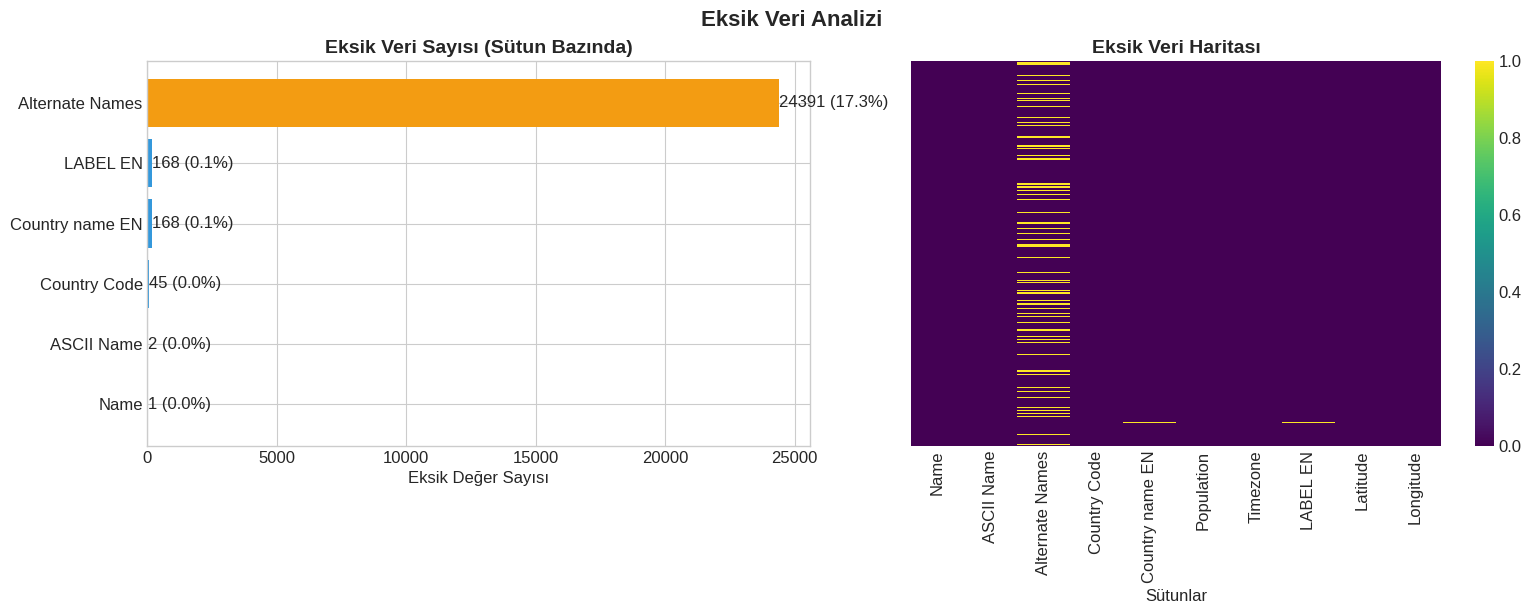

In [ ]:
# Eksik veri görselleştirmesi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
eksik_olan = df.isnull().sum()
eksik_olan = eksik_olan[eksik_olan > 0].sort_values(ascending=True)

colors = ['#e74c3c' if x > 30 else '#f39c12' if x > 10 else '#3498db'
          for x in (eksik_olan / len(df) * 100)]

axes[0].barh(eksik_olan.index, eksik_olan.values, color=colors)
axes[0].set_title('Eksik Veri Sayısı (Sütun Bazında)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Eksik Değer Sayısı')
for i, (val, col) in enumerate(zip(eksik_olan.values, eksik_olan.index)):
    axes[0].text(val + 1, i, f'{val} ({val/len(df)*100:.1f}%)', va='center')

# Heatmap
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=True,
            cmap='viridis',
            ax=axes[1])
axes[1].set_title('Eksik Veri Haritası', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sütunlar')

plt.tight_layout()
plt.suptitle('Eksik Veri Analizi', fontsize=16, fontweight='bold', y=1.02)
plt.show()

 **Eksik Veri Stratejileri**

In [ ]:
# verinin kopyasını aldık
df_temiz = df.copy()


# Alternate Names metin olduğu için Unknown ile doldurduk
df_temiz["Alternate Names"].fillna("Unknown", inplace=True)


# en çok geçen ülke ismini bulduk
en_sik_ulke = df_temiz["Country name EN"].mode()[0]

# boş ülke isimlerini en sık değerle doldurduk
df_temiz["Country name EN"].fillna(en_sik_ulke, inplace=True)


# LABEL EN için de aynı işlemi yaptık
en_sik_label = df_temiz["LABEL EN"].mode()[0]

df_temiz["LABEL EN"].fillna(en_sik_label, inplace=True)


# Population sayısal olduğu için median kullandık
# aykırı değerlerden daha az etkilenir
pop_medyan = df_temiz["Population"].median()

df_temiz["Population"].fillna(pop_medyan, inplace=True)


# eksik veri kaldı mı baktık
print(df_temiz.isnull().sum())

Name                1
ASCII Name          2
Alternate Names     0
Country Code       45
Country name EN     0
Population          0
Timezone            0
LABEL EN            0
Latitude            0
Longitude           0
dtype: int64


***Tek Degiskenli Analiz***

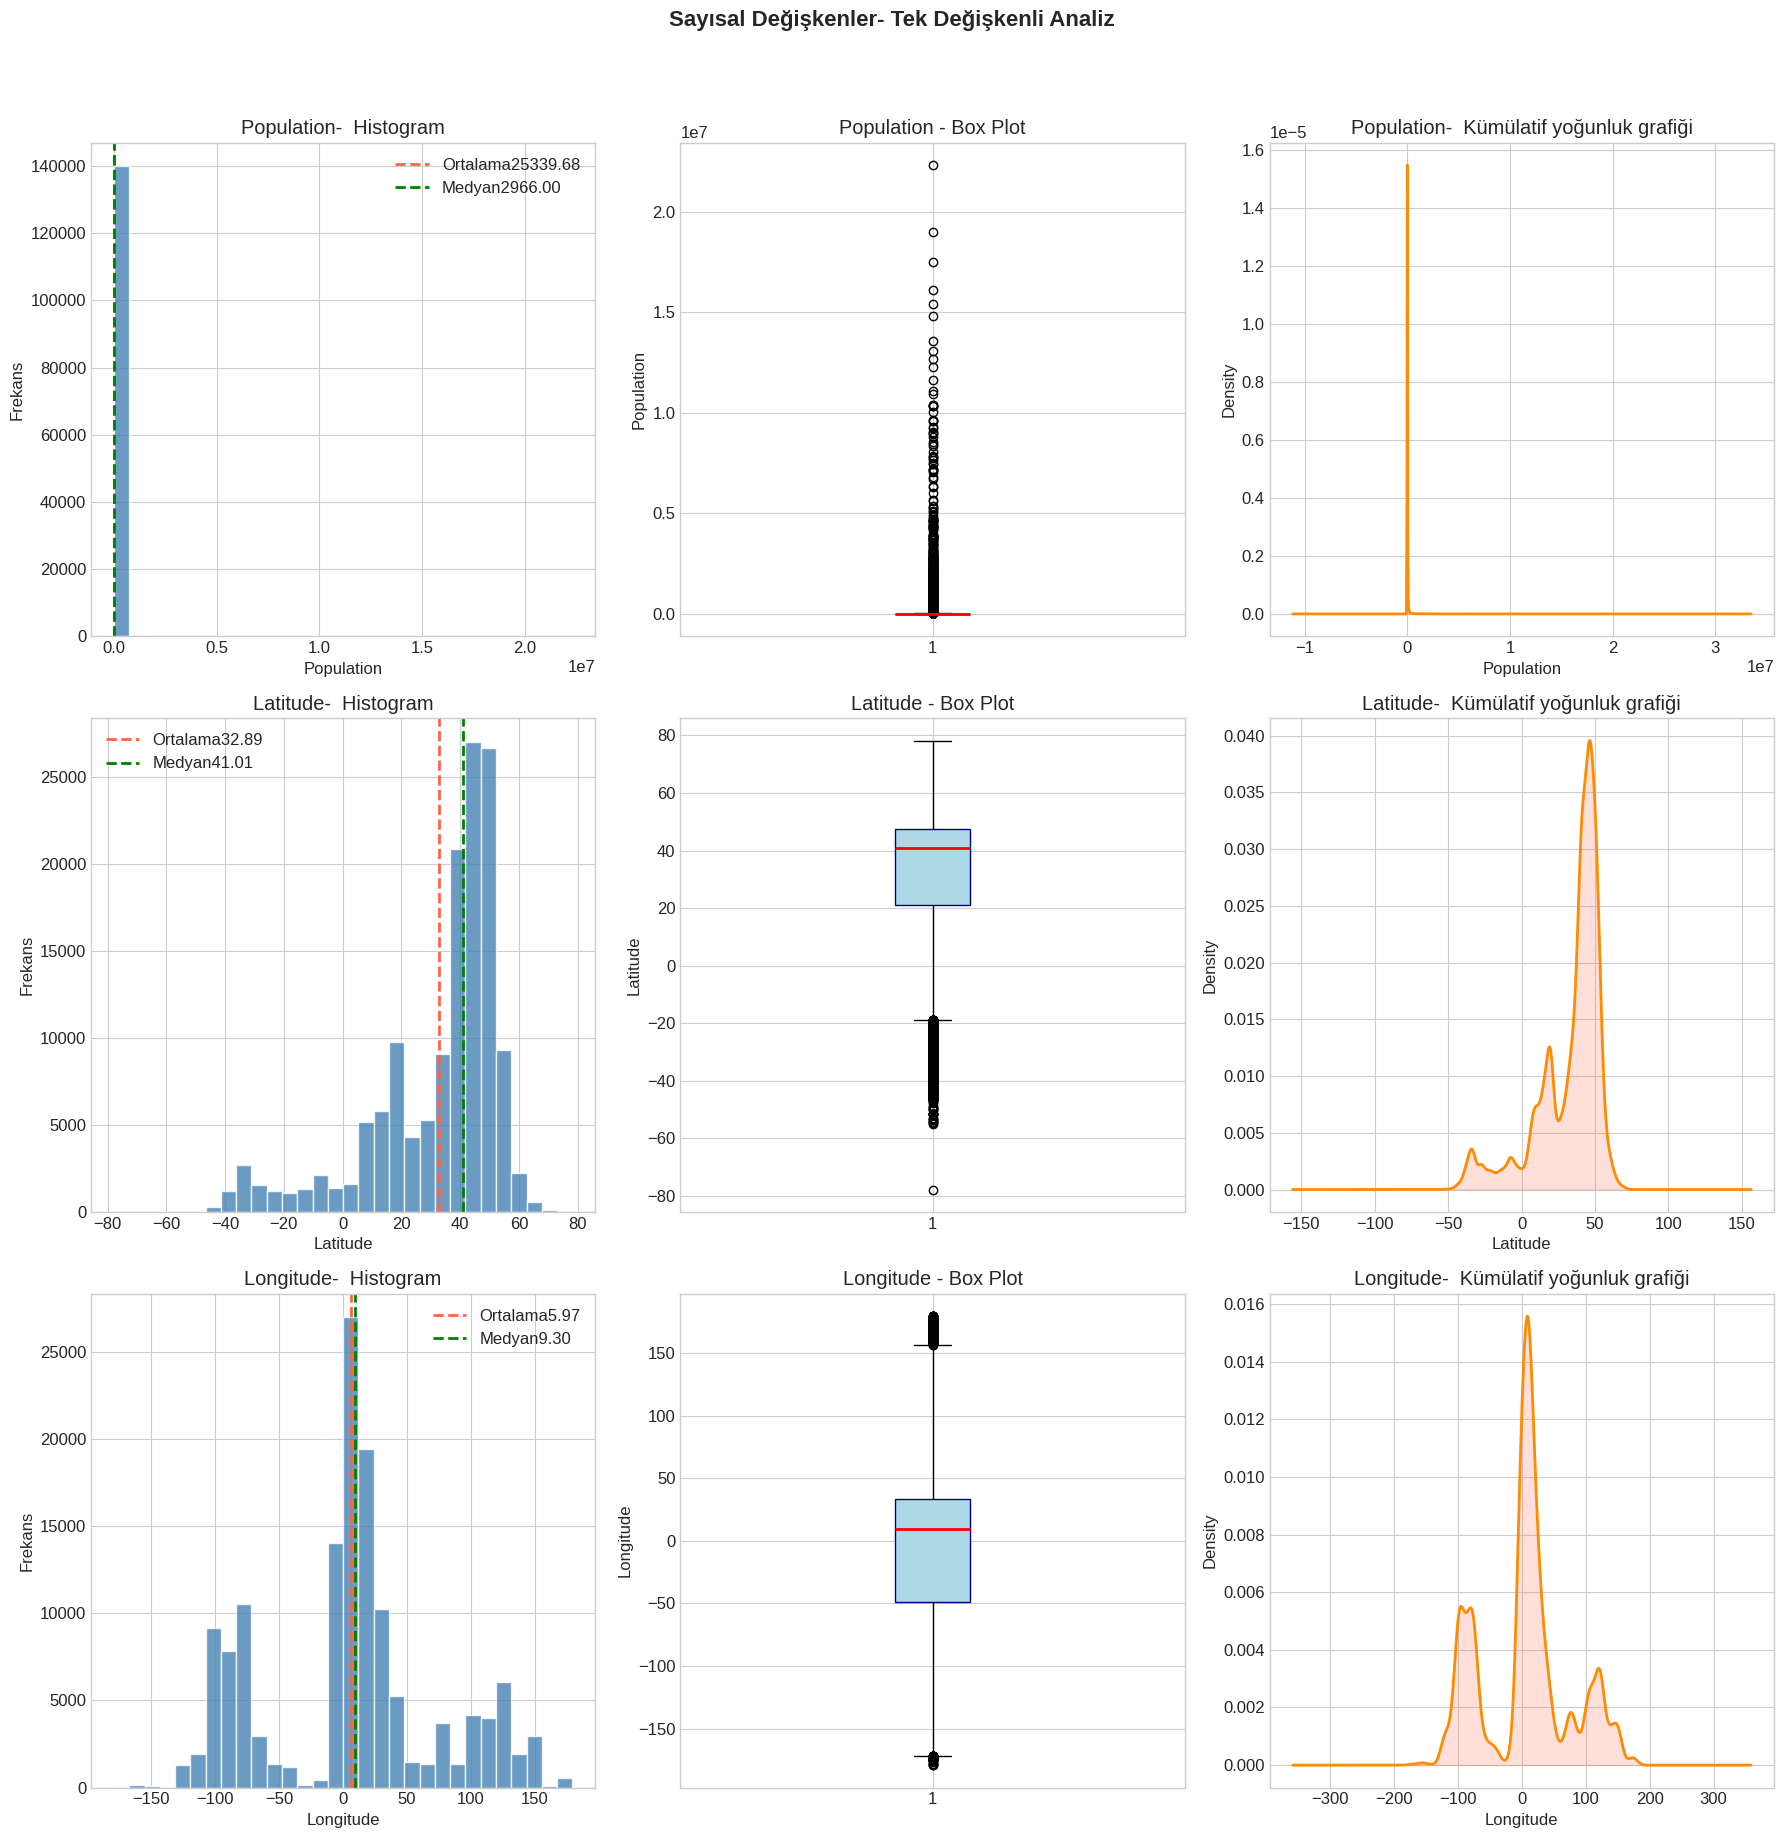

In [ ]:
# sayısal değişkenler

sayisal_kolonlar =['Population','Latitude','Longitude']

fig, axes = plt.subplots(len(sayisal_kolonlar), 3 , figsize=(18, 6*len(sayisal_kolonlar)))

for i, kolon in enumerate(sayisal_kolonlar):
  veri = df_temiz[kolon].dropna()

  axes[i,0].hist(veri, bins=30, color="steelblue",edgecolor='white',alpha=0.8)
  axes[i,0].axvline(veri.mean(), color='tomato', linestyle='dashed', linewidth=2, label=f'Ortalama{veri.mean():.2f}')
  axes[i,0].axvline(veri.median(), color='green', linestyle='dashed', linewidth=2, label=f'Medyan{veri.median():.2f}')
  axes[i,0].set_title(f'{kolon}-  Histogram')
  axes[i,0].legend()
  axes[i,0].set_xlabel(kolon)
  axes[i,0].set_ylabel('Frekans')

      # Box plot
  axes[i, 1].boxplot(veri, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', color='navy'),
                       medianprops=dict(color='red', linewidth=2))
  axes[i, 1].set_title(f'{kolon} - Box Plot')
  axes[i, 1].set_ylabel(kolon)


  veri.plot.kde(ax=axes[i,2],color='darkorange',linewidth=2)
  axes[i,2].fill_between(axes[i,2].lines[0].get_xdata(),
                        axes[i,2].lines[0].get_ydata(),
                        color='tomato',alpha=0.2)
  axes[i,2].set_title(f'{kolon}-  Kümülatif yoğunluk grafiği')
  axes[i,2].set_xlabel(kolon)


plt.suptitle('Sayısal Değişkenler- Tek Değişkenli Analiz', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# istatiksel özet tablo
print('Sayısal Değişkenler detaylı İstatistikler:')
print('='*70)


for kolon in sayisal_kolonlar :
  veri=df_temiz[kolon].dropna()
  print(f'\n * {kolon.upper()}')
  print(f'Ortalama: {veri.mean():.2f}')
  print(f'Medyan: {veri.median():.2f}')
  print(f'Standart Sapma: {veri.std():.2f}')
  print(f'Minimum: {veri.min():.2f}')
  print(f'Maksimum: {veri.max():.2f}')
  print(f'Varyans: {veri.var():.2f}')
  print(f'Skewness(Çarpıklık): {veri.skew():.2f}')
  print(f'Kurtosis(Basıklık): {veri.kurtosis():.2f}')
  print(f'IQR: {veri.quantile(0.75)-veri.quantile(0.25):.2f}')
  print('='*70)

Sayısal Değişkenler detaylı İstatistikler:

 * POPULATION
Ortalama: 25339.68
Medyan: 2966.00
Standart Sapma: 232740.45
Minimum: 0.00
Maksimum: 22315474.00
Varyans: 54168116546.30
Skewness(Çarpıklık): 41.37
Kurtosis(Basıklık): 2416.87
IQR: 8439.25

 * LATITUDE
Ortalama: 32.89
Medyan: 41.01
Standart Sapma: 22.02
Minimum: -77.85
Maksimum: 78.22
Varyans: 484.82
Skewness(Çarpıklık): -1.51
Kurtosis(Basıklık): 1.85
IQR: 26.63

 * LONGITUDE
Ortalama: 5.97
Medyan: 9.30
Standart Sapma: 68.67
Minimum: -179.12
Maksimum: 179.36
Varyans: 4715.10
Skewness(Çarpıklık): 0.12
Kurtosis(Basıklık): -0.43
IQR: 82.02


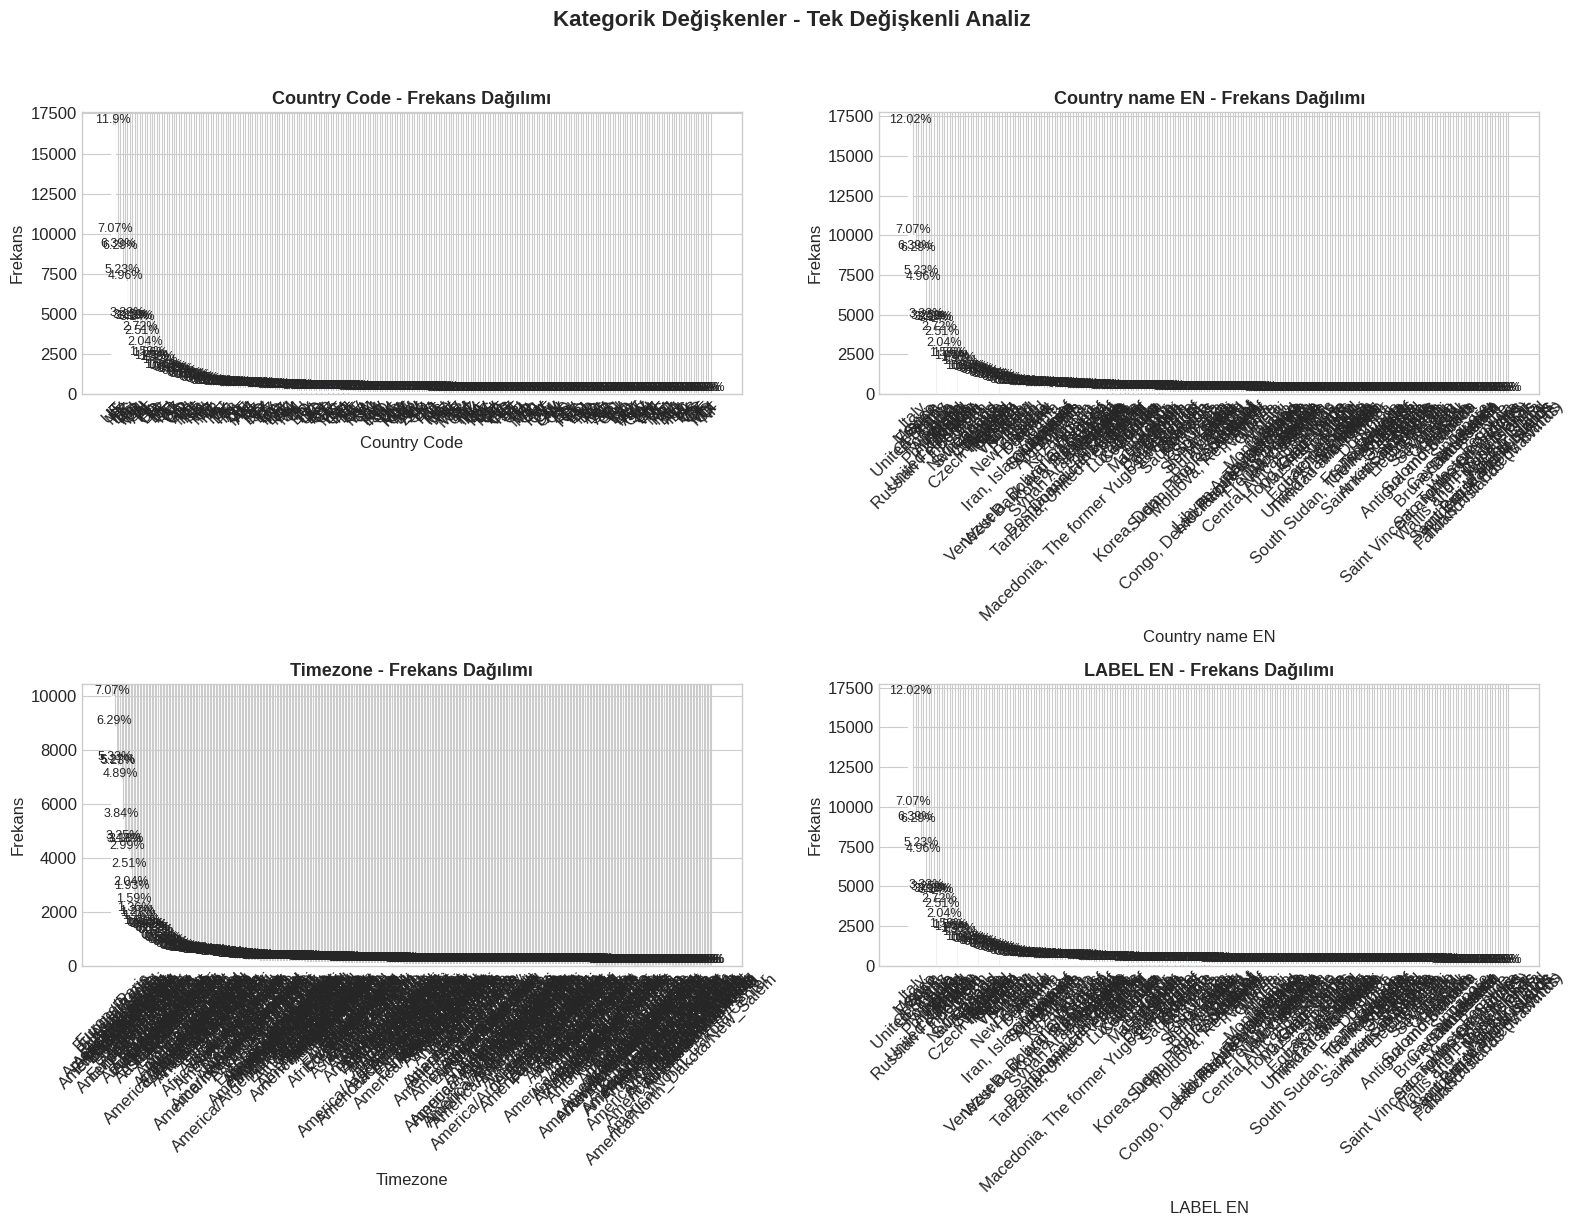

In [ ]:

kategorik_kolonlar = [
    'Country Code',
    'Country name EN',
    'Timezone',
    'LABEL EN'
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

renkler = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA94D', '#845EF7', '#F06595']

for i, kolon in enumerate(kategorik_kolonlar):
    degerler = df_temiz[kolon].value_counts()
    yuzde = (degerler / len(df_temiz) * 100).round(2)

    bars = axes[i].bar(
        degerler.index.astype(str),
        degerler.values,
        color=renkler[:len(degerler)],
        edgecolor='white',
        linewidth=2
    )

    axes[i].set_title(f'{kolon} - Frekans Dağılımı', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(kolon)
    axes[i].set_ylabel('Frekans')

    axes[i].tick_params(axis='x', rotation=45)

    for bar, pct in zip(bars, yuzde.values):
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{pct}%',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.suptitle('Kategorik Değişkenler - Tek Değişkenli Analiz',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()



***Çift değişkenli Analiz***

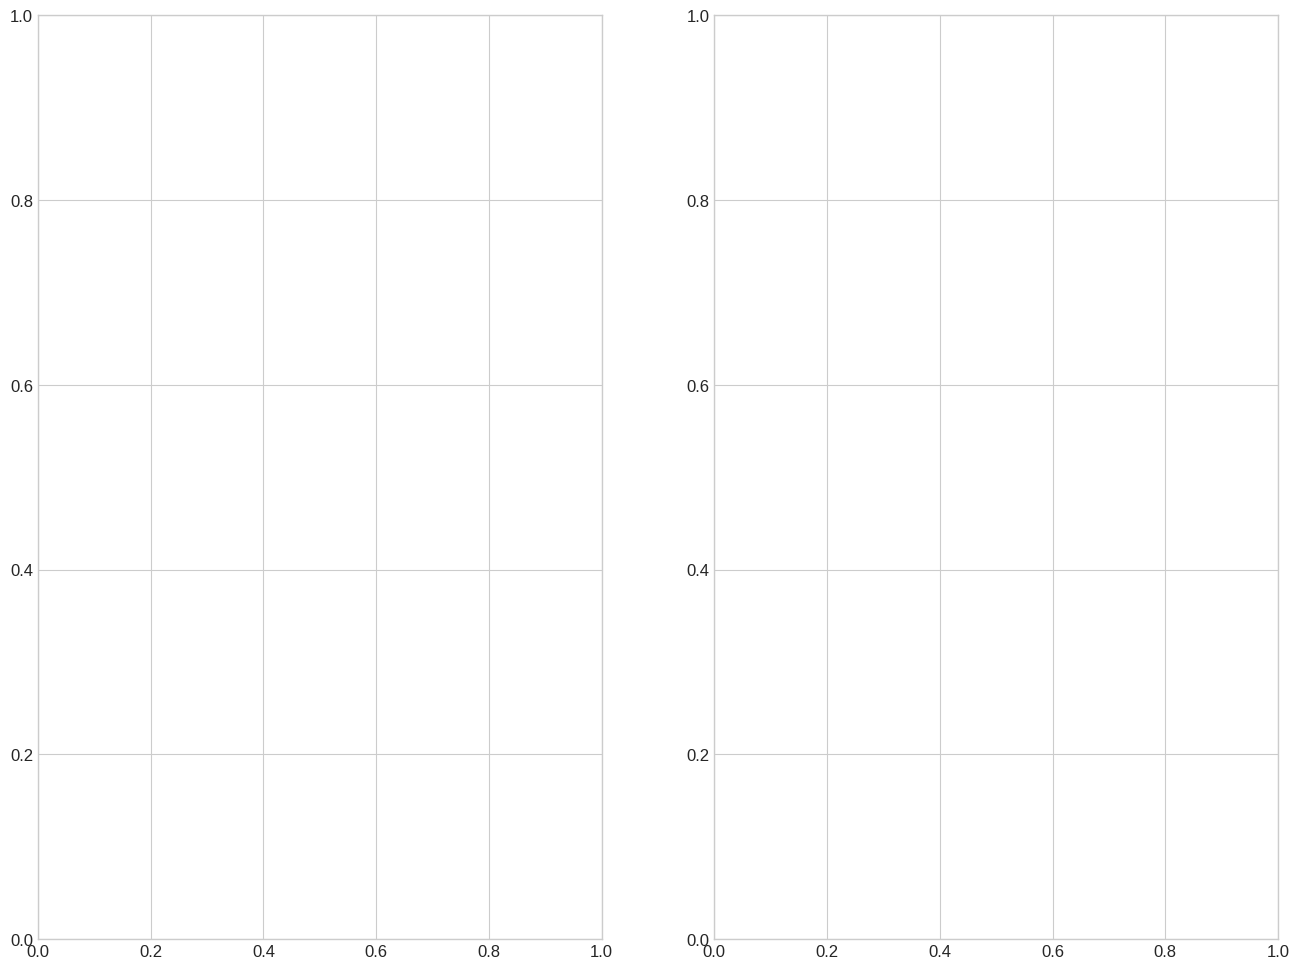

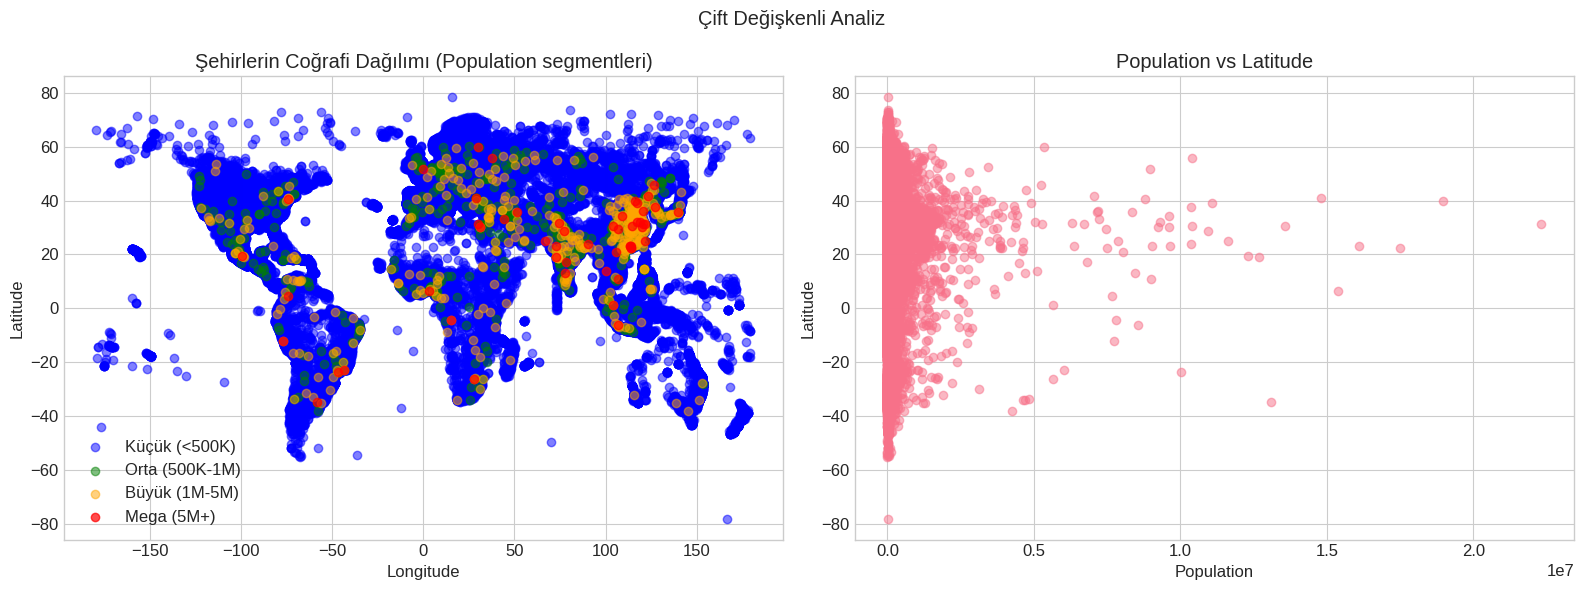

In [ ]:
#sayısal vs Sayısal : Scatter Plot

fig,axes = plt.subplots(1,2,figsize=(16,12))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# 1) Latitude - Longitude (Population segmentleri)


kucuk = df_temiz[df_temiz['Population'] < 500_000]

orta = df_temiz[(df_temiz['Population'] >= 500_000) & (df_temiz['Population'] < 1_000_000)]

buyuk = df_temiz[(df_temiz['Population'] >= 1_000_000) & (df_temiz['Population'] < 5_000_000)]

mega = df_temiz[df_temiz['Population'] >= 5_000_000]

axes[0].scatter(kucuk['Longitude'], kucuk['Latitude'], color='blue', label='Küçük (<500K)', alpha=0.5)

axes[0].scatter(orta['Longitude'], orta['Latitude'], color='green', label='Orta (500K-1M)', alpha=0.5)

axes[0].scatter(buyuk['Longitude'], buyuk['Latitude'], color='orange', label='Büyük (1M-5M)', alpha=0.5)

axes[0].scatter(mega['Longitude'], mega['Latitude'], color='red', label='Mega (5M+)', alpha=0.7)

axes[0].set_xlabel('Longitude')

axes[0].set_ylabel('Latitude')

axes[0].set_title('Şehirlerin Coğrafi Dağılımı (Population segmentleri)')

axes[0].legend()

axes[1].scatter(df_temiz['Population'], df_temiz['Latitude'], alpha=0.5)

axes[1].set_xlabel('Population')

axes[1].set_ylabel('Latitude')

axes[1].set_title('Population vs Latitude')

plt.suptitle('Çift Değişkenli Analiz')

plt.tight_layout()

plt.show()

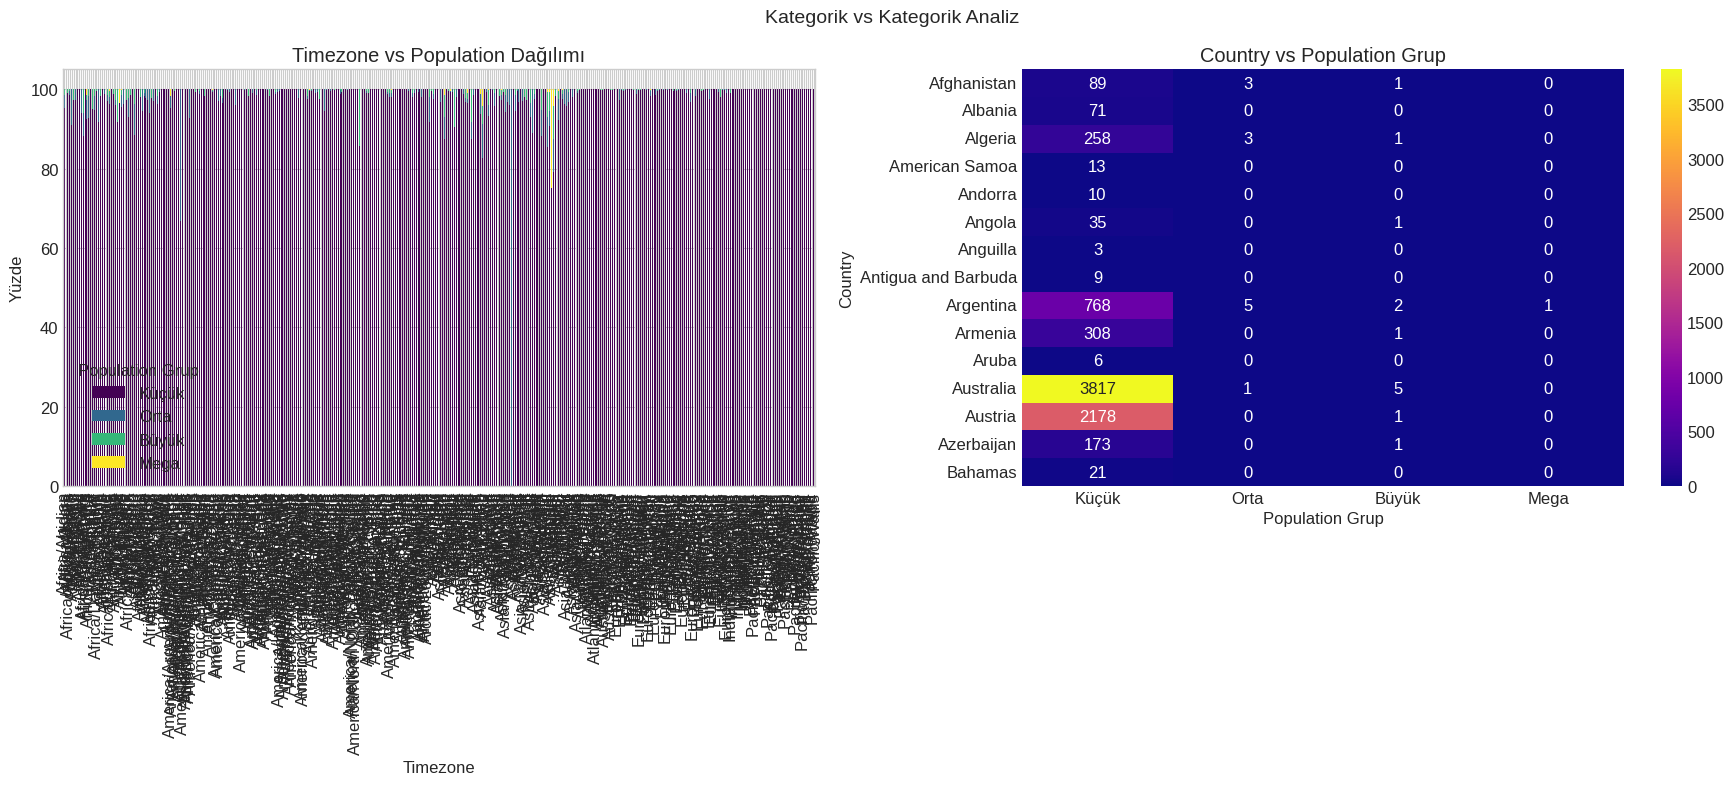

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -------------------------
# POP GRUP
# -------------------------
df_temiz['pop_grup'] = pd.cut(
    df_temiz['Population'],
    bins=[0, 500_000, 1_000_000, 5_000_000, float('inf')],
    labels=['Küçük', 'Orta', 'Büyük', 'Mega']
)

# -------------------------
# FIGURE
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# -------------------------
# 1. TIMEZONE vs POP
# -------------------------
ct_pct = pd.crosstab(
    df_temiz['Timezone'],
    df_temiz['pop_grup'],
    normalize='index'
) * 100

ct_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')

axes[0].set_title('Timezone vs Population Dağılımı')
axes[0].set_xlabel('Timezone')
axes[0].set_ylabel('Yüzde')
axes[0].tick_params(axis='x', rotation=90)
axes[0].legend(title='Population Grup')

# -------------------------
# 2. COUNTRY vs POP
# -------------------------
ct2 = pd.crosstab(df_temiz['Country name EN'], df_temiz['pop_grup'])
ct2 = ct2.head(15)

sns.heatmap(ct2, annot=True, fmt='d', cmap='plasma', ax=axes[1])

axes[1].set_title('Country vs Population Grup')
axes[1].set_xlabel('Population Grup')
axes[1].set_ylabel('Country')

# -------------------------
plt.suptitle('Kategorik vs Kategorik Analiz', fontsize=14)
plt.tight_layout()
plt.show()

